In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
store_sales = pd.read_csv("D:/DataScience/retail_sales_forcasting/dataset/monthly_sales.csv")
store_sales.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [3]:
store_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [4]:
store_sales = store_sales.drop(['store', 'item'], axis=1)

In [5]:
store_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   sales   913000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 13.9+ MB


In [6]:
store_sales['date'] = pd.to_datetime(store_sales['date'])

In [7]:
store_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 13.9 MB


In [8]:
store_sales['date'] = store_sales['date'].dt.to_period("M")
monthly_sales = store_sales.groupby('date').sum().reset_index()

In [9]:
monthly_sales['date'] = monthly_sales['date'].dt.to_timestamp()

In [10]:
monthly_sales.head()

,date,sales
0,2013-01-01,454904
1,2013-02-01,459417
2,2013-03-01,617382
3,2013-04-01,682274
4,2013-05-01,763242


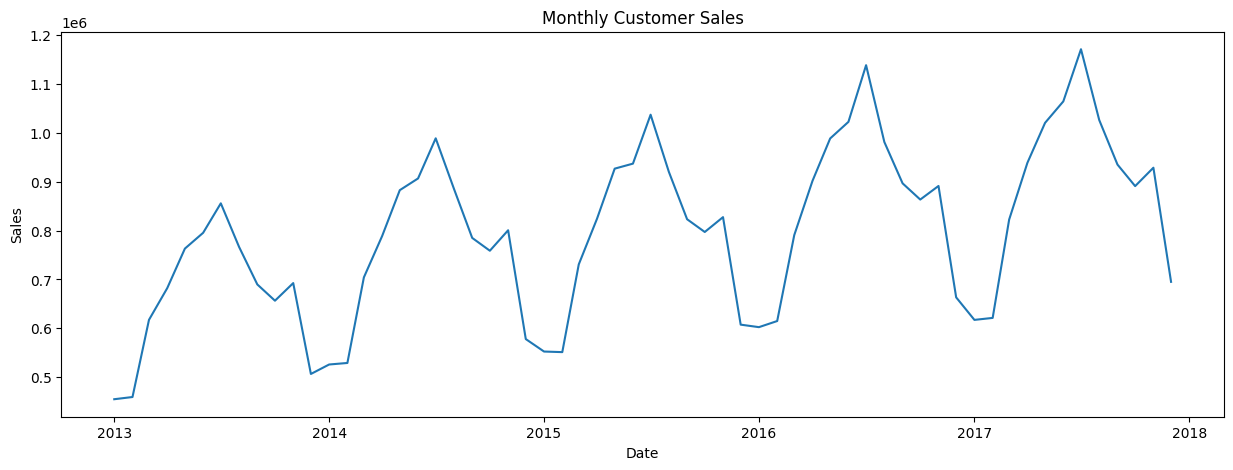

In [11]:
# visualization
plt.figure(figsize=(15,5))
plt.plot(monthly_sales['date'], monthly_sales['sales'])
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Monthly Customer Sales")
plt.show()

In [12]:
monthly_sales['sales_diff'] = monthly_sales['sales'].diff()
monthly_sales  = monthly_sales.dropna()
monthly_sales.head()

,date,sales,sales_diff
1,2013-02-01,459417,4513.0
2,2013-03-01,617382,157965.0
3,2013-04-01,682274,64892.0
4,2013-05-01,763242,80968.0
5,2013-06-01,795597,32355.0


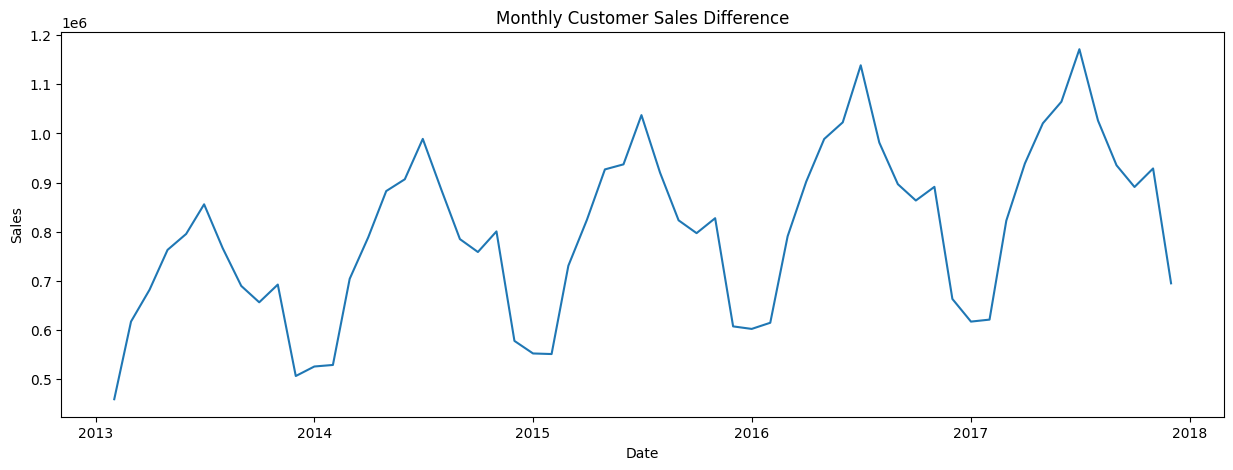

In [13]:
plt.figure(figsize=(15,5))
plt.plot(monthly_sales['date'], monthly_sales['sales'])
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Monthly Customer Sales Difference")
plt.show()

In [35]:
supervised_data = monthly_sales.drop(['date', 'sales'], axis=1)

In [36]:
for i in range(1,13):
    col_name = 'month_' + str(i)
    supervised_data[col_name] = supervised_data['sales_diff'].shift(i)
supervised_data = supervised_data.dropna().reset_index(drop=True)
supervised_data.head()

,sales_diff,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,3130.0,19380.0,-186036.0,36056.0,-33320.0,-76854.0,-89161.0,60325.0,32355.0,80968.0,64892.0,157965.0,4513.0
1,175184.0,3130.0,19380.0,-186036.0,36056.0,-33320.0,-76854.0,-89161.0,60325.0,32355.0,80968.0,64892.0,157965.0
2,84613.0,175184.0,3130.0,19380.0,-186036.0,36056.0,-33320.0,-76854.0,-89161.0,60325.0,32355.0,80968.0,64892.0
3,93963.0,84613.0,175184.0,3130.0,19380.0,-186036.0,36056.0,-33320.0,-76854.0,-89161.0,60325.0,32355.0,80968.0
4,23965.0,93963.0,84613.0,175184.0,3130.0,19380.0,-186036.0,36056.0,-33320.0,-76854.0,-89161.0,60325.0,32355.0


In [37]:
# Splitting data into train and test sets
train_data = supervised_data[:-12]
test_data = supervised_data[-12:]

print("Train data shape: ", train_data.shape)
print("Test data shape: ", test_data.shape)

Train data shape:  (35, 13)
Test data shape:  (12, 13)


In [38]:
# Scaling features
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(train_data)
train_data = scaler.transform(train_data)
test_data = scaler.transform(test_data)

In [39]:
# Splitting data into input and output
x_train, y_train = train_data[:, 1:], train_data[:, 0:1]
x_test, y_test = test_data[:, 1:], test_data[:, 0:1]

y_train = y_train.ravel()
y_test = y_test.ravel()

print("x_train shape: ", x_train.shape)
print("y_train shape: ", y_train.shape)
print("x_test shape: ", x_test.shape)
print("y_test shape: ", y_test.shape)


x_train shape:  (35, 12)
y_train shape:  (35,)
x_test shape:  (12, 12)
y_test shape:  (12,)


In [40]:
# Creating a DataFrame to store predictions
sales_dates = monthly_sales['date'][-12:].reset_index(drop=True)
predict_df = pd.DataFrame(sales_dates)

In [41]:
actual_sales = monthly_sales['sales'][-13:].to_list()
print(actual_sales)

[663411, 617306, 621369, 822667, 938862, 1020686, 1064624, 1171393, 1026403, 935263, 891160, 928837, 695170]


In [42]:
# Train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)
lr_predict = lr_model.predict(x_test)

In [43]:
lr_predict = lr_predict.reshape(-1,1)
# set matrix - contains the input features of the test data, and also the predicted output
lr_predict_test_set = np.concatenate([lr_predict, x_test], axis=1)
lr_predict_test_set = scaler.inverse_transform(lr_predict_test_set)

In [44]:
# Calculating predicted sales
result_list = []
for index in range(0, len(lr_predict_test_set)):
    result_list.append(lr_predict_test_set[index][0] + actual_sales[index])

lr_predict_series = pd.Series(result_list, name='linear_prediction')

# Merging with prediction DataFrame
predict_df = predict_df.merge(lr_predict_series, left_index=True, right_index=True)

In [27]:
predict_df["Actual_Sales"] = monthly_sales["sales"][-12:].reset_index(drop=True)

In [28]:
predict_df.rename(
    columns={"linear_prediction": "Predicted_Sales"},
    inplace=True
)

In [29]:
predict_df = predict_df[
    ["date", "Actual_Sales", "Predicted_Sales"]
]

In [30]:
predict_df

,date,Actual_Sales,Predicted_Sales
0,2017-01-01,617306,6.479148e+05
1,2017-02-01,621369,6.283374e+05
2,2017-03-01,822667,8.195190e+05
3,2017-04-01,938862,9.436391e+05
4,2017-05-01,1020686,1.033653e+06
5,2017-06-01,1064624,1.065286e+06
6,2017-07-01,1171393,1.201561e+06
7,2017-08-01,1026403,1.002123e+06
8,2017-09-01,935263,9.415142e+05
9,2017-10-01,891160,9.080646e+05


In [31]:
predict_df.to_csv(
    "sales_forecast_results.csv",
    index=False
)

In [32]:
monthly_sales.to_csv(
    "monthly_sales_dashboard.csv",
    index=False
)

In [45]:
# Model Evaluation
lr_mse = np.sqrt(mean_squared_error(predict_df['linear_prediction'], monthly_sales['sales'][-12:]))
lr_mae = mean_absolute_error(predict_df['linear_prediction'], monthly_sales['sales'][-12:])
lr_r2 = r2_score(predict_df['linear_prediction'], monthly_sales['sales'][-12:])

print(f"Linear Regression MSE: {lr_mse}")
print(f"Linear Regression MAE: {lr_mae}")
print(f"Linear Regression R2 Score: {lr_r2}")

Linear Regression MSE: 16221.272385416896
Linear Regression MAE: 12433.184266490784
Linear Regression R2 Score: 0.9906152516380968


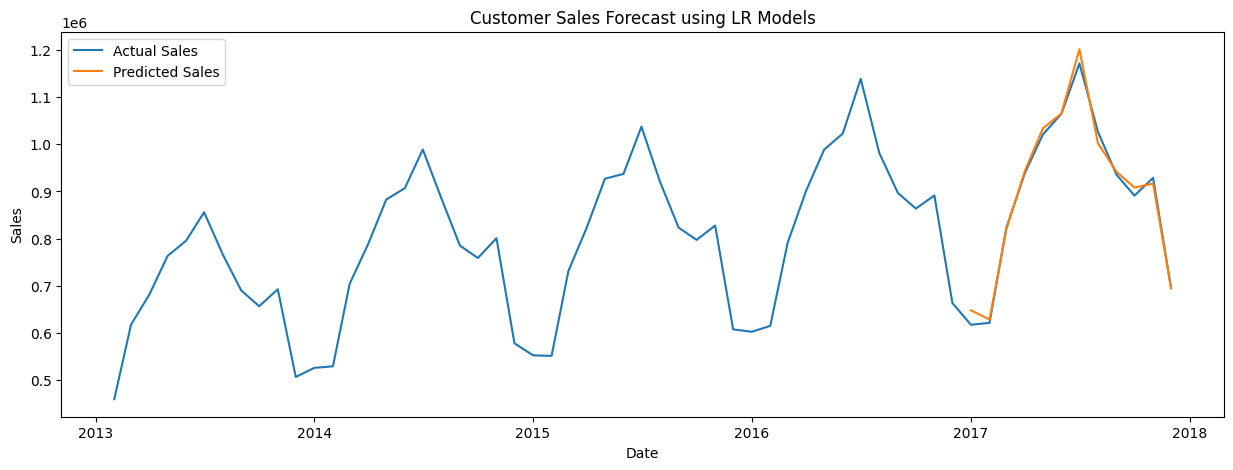

In [47]:
# visualization of predicted against actual sales
plt.figure(figsize=(15,5))
# Actual sales
plt.plot(monthly_sales['date'], monthly_sales['sales'])
# Predicted sales
plt.plot(predict_df['date'], predict_df['linear_prediction'])
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Customer Sales Forecast using LR Models")
plt.legend(['Actual Sales', 'Predicted Sales'])
plt.show()